In [1]:
import os, glob
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import numpy.ma as ma
from skimage import io
import pandas as pd
import pyFAI

In [2]:
%matplotlib widget

In [3]:
from tiled.client import from_profile, from_uri

In [4]:
tiled_client = from_profile('pdf')

In [5]:
pilatus_config:str = '/nsls2/data3/pdf/pdfhack/legacy/processed/xpdacq_data/user_data/config_base/pilatus_PDF/'
masks_pos_flist = ['Mask_pos1_ext_BS.npy', 'Mask_pos2_ext_BS.npy', 'Mask_pos3_ext_BS.npy']
m1_path = os.path.join(pilatus_config, masks_pos_flist[0])
m2_path = os.path.join(pilatus_config, masks_pos_flist[1])
m3_path = os.path.join(pilatus_config, masks_pos_flist[2])
# use_mask_1= np.load(m1_path)  # This is mask we are applying befor mergin images
# use_mask_2 = np.load(m2_path) # This is mask we are applying befor mergin images
# use_mask_3 = np.load(m3_path) # This is mask we are applying befor mergin images

mask_stitched_path:str = os.path.join(pilatus_config, 'Mask_stitched.npy')
mask_stitched:np.array = np.load(mask_stitched_path)
mask_stitched.shape

(1733, 1529)

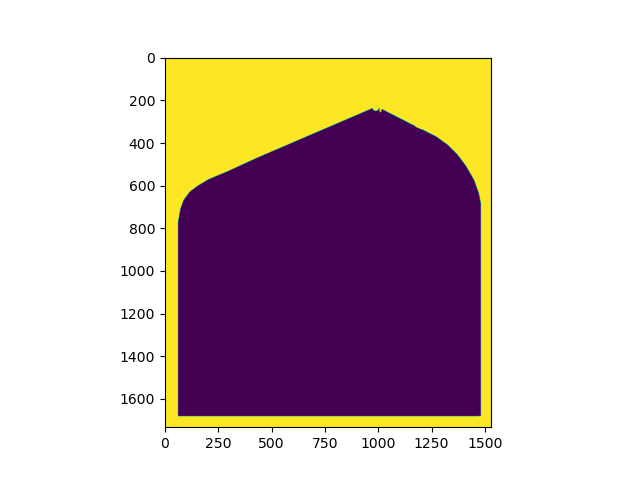

In [6]:
plt.figure()
plt.imshow(mask_stitched)

In [36]:
tiff_base = '/nsls2/data3/pdf/pdfhack/legacy/processed/xpdacq_data/user_data/tiff_base/'
sample_name = 'empty_quartz_A'
tiff_path = os.path.join(tiff_base, sample_name, 'pilatus-1', '**.tiff')
tiff_list = glob.glob(tiff_path)
tiff_list.sort()
print(*[os.path.basename(tiff) for tiff in tiff_list], sep='\n')

empty_quartz_A_20251121-105306_64aa5a_300_K_sum.tiff


In [37]:
sum_img = io.imread(tiff_list[0])
sum_img.shape

(1733, 1529)

In [38]:
poni_stitched_path:str = os.path.join(pilatus_config, 'merged.poni')
ai:pyFAI.integrator.azimuthal.AzimuthalIntegrator = pyFAI.load(poni_stitched_path)


## perform azimuthalintegration on one image to retain 2D information
## i2d.shape is (self.npt_azim, self.npt_rad) which corresponds the intensity of 2D image cake
## q1d.shape is (self.npt_rad, )
i2d_m, q1d_m, chi1d_m = ai.integrate2d(sum_img, 4096, 
                                 unit='q_A^-1', npt_azim=3600, 
                                 polarization_factor=0.99, 
                                 mask=mask_stitched)

i2d, q1d, chi1d = ai.integrate2d(sum_img, 4096, 
                                 unit='q_A^-1', npt_azim=3600, 
                                 polarization_factor=0.99, )
                                 # mask=mask_stitched)

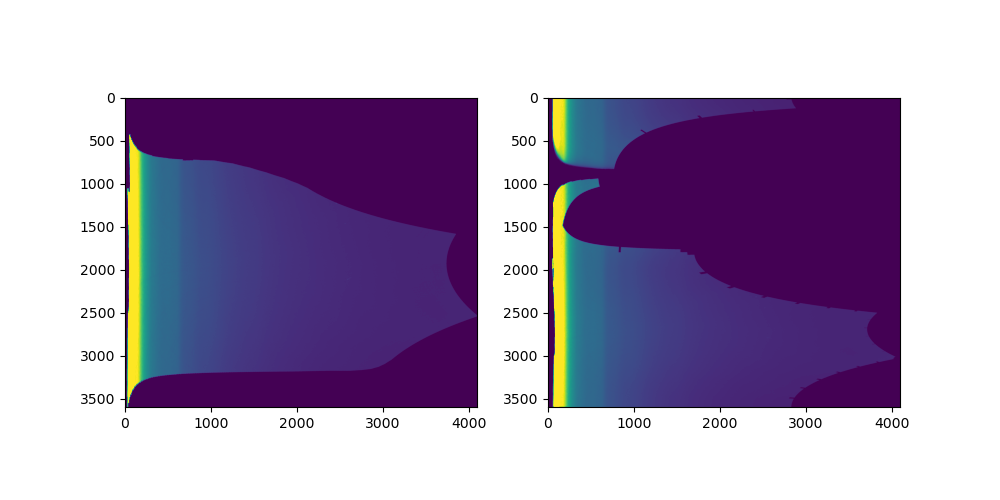

In [39]:
f0 = plt.figure(figsize=(10, 5))
gs = GridSpec(nrows=1, ncols=2, width_ratios=[1.0, 1.0])

ax0 = f0.add_subplot(gs[:,0])
ax0.imshow(i2d_m, vmin=np.percentile(i2d_m, 2), vmax=np.percentile(i2d_m, 98))

ax0 = f0.add_subplot(gs[:,1])
ax0.imshow(i2d, vmin=np.percentile(i2d, 2), vmax=np.percentile(i2d, 98))

In [40]:
## trasnform self.mask_array (base mask) to the same coordinate space and cast it as type bool
intrinsic_mask_unrolled, _, _ = ai.integrate2d(mask_stitched, 4096, 
                                               unit='q_A^-1', npt_azim=3600, 
                                               polarization_factor=0.99,)

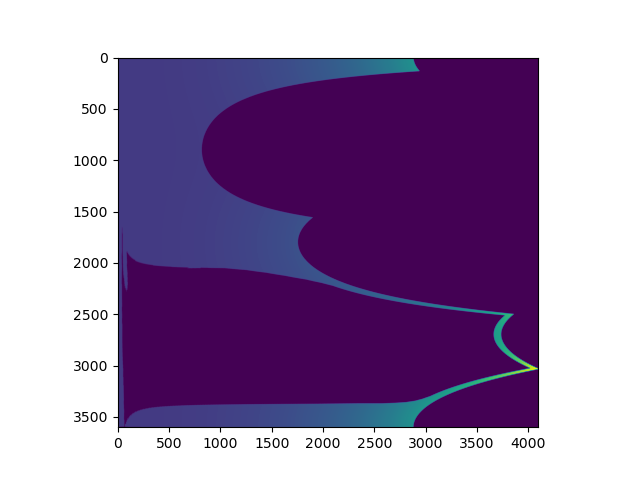

In [41]:
plt.figure()
plt.imshow(intrinsic_mask_unrolled)

In [42]:
## Create an array to hold outlier mask
outlier_mask_2d = np.zeros_like(i2d)     
mask1 = np.array(i2d<1)*1  ## Change to <0 by CHL on 2025/11/12

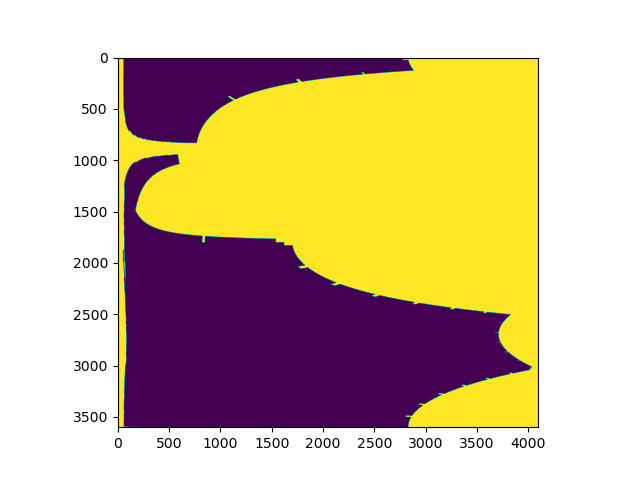

In [43]:
plt.figure()
plt.imshow(mask1)
# plt.imshow(intrinsic_mask_unrolled, alpha=0.5)

In [44]:
## Apply percentile filter along radial direction (axis=0)
ll = 2
ul = 98
for ii, dd in enumerate(i2d.T):
    low_limit, high_limit = np.percentile(dd, (ll, ul))
    outlier_mask_2d[:,ii] = np.any([dd<low_limit, dd>high_limit, intrinsic_mask_unrolled[:,ii]], axis=0)

outlier_mask_2d_masked = ma.masked_array(i2d, mask=outlier_mask_2d + mask1)
# outlier_mask_2d_masked = ma.masked_array(i2d, mask=outlier_mask_2d)

In [45]:
outlier_mask_2d_masked

masked_array(
  data=[[--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        ...,
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --]],
  mask=[[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],
  fill_value=1e+20,
  dtype=float32)

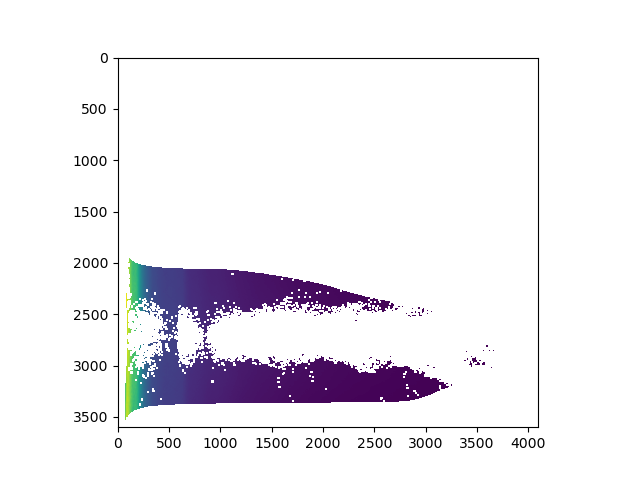

In [46]:
plt.figure()
plt.imshow(outlier_mask_2d_masked)

In [47]:
## calculate mean values along radial direction (axis=0) to make i1d.shape is (self.npt_rad, )
i1d = ma.mean(outlier_mask_2d_masked, axis=0)

iq_df0 = pd.DataFrame()
iq_df0['q'] = q1d
iq_df0['I'] = i1d
# iq_df = iq_df0.dropna()
iq_df = iq_df0.fillna(0)

fn_iq = f'{tiff_list[0][:-5]}_mask.xy'
iq_df.to_csv(fn_iq, sep=' ', index=False, header=False, float_format='{:.8e}'.format)

In [28]:
iq_df.shape

(4096, 2)

In [29]:
iq_df.iloc[:,0]

0        0.004152
1        0.012455
2        0.020759
3        0.029063
4        0.037366
          ...    
4091    33.974101
4092    33.982405
4093    33.990708
4094    33.999012
4095    34.007316
Name: q, Length: 4096, dtype: float64

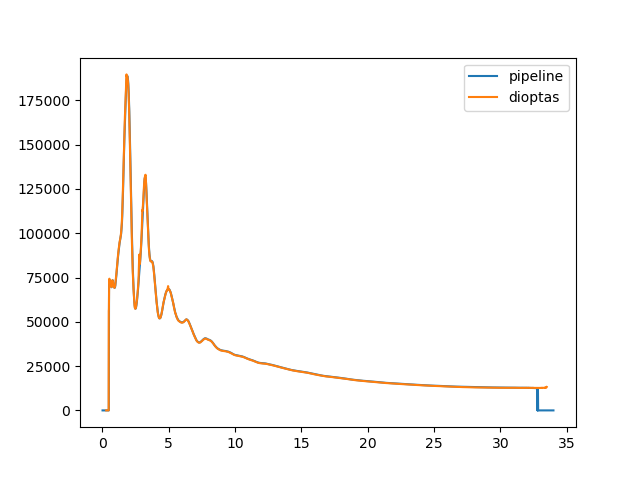

In [31]:
fn_xy = '/nsls2/data3/pdf/pdfhack/legacy/processed/xpdacq_data/user_data/tiff_base/DL_35dme_A/pilatus-1/DL_35dme_A_20251121-131540_fc790a_100_K_sum.xy'
df_xy = pd.read_csv(fn_xy, skiprows=23, names=['q', 'Iq'], sep=' ')

plt.figure()
plt.plot(iq_df.iloc[:,0], iq_df.iloc[:,1], label='pipeline')
plt.plot(df_xy.iloc[:,0], df_xy.iloc[:,1], label='dioptas')
plt.legend()